<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Synthetic Dataset Generation with LLM Agent and Statistics**


Estimated time needed: **90** minutes


Master the art of creating high-quality synthetic datasets using cutting-edge AI techniques! This hands-on project will teach you to generate realistic, privacy-preserving data for machine learning applications. You'll learn to leverage large language models, implement advanced sampling strategies, and create comprehensive synthetic datasets that maintain statistical properties of real data.

Here's your challenge: You've been hired by "DataHealth," a healthcare analytics company facing a critical problem. The Chief Data Officer explains: "We have incredible machine learning models, but our clients can't share patient data due to HIPAA regulations. We need synthetic datasets that preserve statistical relationships and patterns from real medical data, but contain zero actual patient information. Our data scientists spend weeks manually creating test datasets that still don't capture the complexity of real-world scenarios."

You'll solve this by building a comprehensive synthetic data generation pipeline using modern techniques including LLM-based generation, statistical sampling, GAN-inspired approaches, and validation frameworks - transforming the challenge of data scarcity into an opportunity for privacy-preserving innovation.


## Table of contents
1. [Learning Objectives](#Learning-Objectives)
2. [Setup](#Setup)
   - [Installing Required Libraries](#Installing-Required-Libraries)
   - [Importing Required Libraries](#Importing-Required-Libraries)
3. [Project Roadmap](#Project-Roadmap)
   - [Synthetic Data Generation Overview](#Synthetic-Data-Generation-Overview)
   - [Modern Approaches to Synthetic Data](#Modern-Approaches-to-Synthetic-Data)
   - [Implementation Strategy](#Implementation-Strategy)
4. [Building the Synthetic Data Generator](#Building-the-Synthetic-Data-Generator)
   - [Configuring the LLM](#Configuring-the-LLM)
   - [Creating Statistical Samplers](#Creating-Statistical-Samplers)
   - [Building LLM-Based Data Generators](#Building-LLM-Based-Data-Generators)
   - [Implementing Conditional Generation](#Implementing-Conditional-Generation)
   - [Data Validation and Quality Metrics](#Data-Validation-and-Quality-Metrics)
   - [Complete Pipeline Integration](#Complete-Pipeline-Integration)
5. [Exercises](#Exercises)
   - [Exercise 1 - Multi-Modal Data Generation](#Exercise-1---Multi-Modal-Data-Generation)
   - [Exercise 2 - Privacy Validation Framework](#Exercise-2---Privacy-Validation-Framework)


## Learning Objectives

After completing this lab you will be able to:
- Build comprehensive synthetic data generation pipelines using modern AI techniques
- Leverage large language models for realistic text and structured data generation
- Implement statistical sampling methods that preserve data distributions
- Create validation frameworks to ensure synthetic data quality and privacy

---


## Setup


For this lab, we will be using the following libraries:

* [`langchain`](https://python.langchain.com/) for orchestrating LLM-based data generation
* [`langchain-openai`](https://python.langchain.com/docs/integrations/chat/openai/) for accessing GPT models
* [`faker`](https://faker.readthedocs.io/) for generating realistic fake data
* [`sdv`](https://sdv.dev/) (Synthetic Data Vault) for advanced statistical generation
* [`pandas`](https://pandas.pydata.org/) for data manipulation and analysis
* [`numpy`](https://numpy.org/) for numerical operations and statistical sampling
* [`scipy`](https://scipy.org/) for advanced statistical distributions


### Installing Required Libraries

Installing all libraries may take a while (upto 20 minutes), please be patient. 


### Importing Required Libraries


In [3]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import json
from typing import List, Dict, Any, Optional
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from faker import Faker
from sdv.single_table import GaussianCopulaSynthesizer, CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

from langchain_openai import OpenAI, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain.chat_models import init_chat_model

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Keyword Dictionary 

Before we start writing code, let's make sure we're on the same page. Below you'll find a word bank of all the important terms you'll need to know in order to meaningfully work through this project. Feel free to reference this dictionary any time. 

| Term           | Definition                                                                                                                                                                                                                     |
| -------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Synthetic Data**        | **Synthetic Data** is artificially generated data that mimics the statistical properties and patterns of real data, but contains no actual real-world observations or personally identifiable information.                    |
| **LLM-Based Generation**   | **LLM-Based Generation** uses large language models to create realistic synthetic data by learning patterns from examples and generating new instances that follow similar structures and distributions.                      |
| **Statistical Sampling** | **Statistical Sampling** involves using probability distributions and statistical methods to generate synthetic data that preserves the mathematical properties of the original dataset. |
| **Copula Methods** | **Copula Methods** are statistical techniques that model the dependency structure between variables separately from their individual distributions, enabling realistic multi-variate synthetic data generation. |
| **Privacy Preservation** | **Privacy Preservation** ensures that synthetic data cannot be reverse-engineered to reveal information about individuals in the original dataset, protecting sensitive information. |


## Project Roadmap

### Synthetic Data Generation Overview

Synthetic data generation has become essential in modern data science for several critical use cases:

- **Privacy Protection**: Generate datasets that preserve analytical utility without exposing sensitive information
- **Data Augmentation**: Expand limited datasets to improve machine learning model performance
- **Testing & Development**: Create realistic test datasets for software development and QA
- **Bias Mitigation**: Generate balanced datasets to address representation gaps
- **Compliance**: Meet regulatory requirements while enabling data sharing and collaboration
  
In this project, we'll create a comprehensive synthetic data generation system that combines statistical methods with modern LLM techniques to produce high-quality, realistic datasets.


---
### Modern Approaches to Synthetic Data

Contemporary synthetic data generation employs multiple techniques:

- **Statistical Methods**: Use probability distributions, copulas, and sampling techniques
- **LLM-Based Generation**: Leverage language models to create realistic text and structured data
- **GAN Approaches**: Use Generative Adversarial Networks for complex data synthesis
- **Hybrid Methods**: Combine multiple approaches for optimal results
- **Conditional Generation**: Create synthetic data that respects specific constraints and relationships

This architecture allows us to handle diverse data types while maintaining quality, realism, and privacy guarantees.


### Implementation Strategy

Our approach:
1. **Build Statistical Generators**: Implement sampling from distributions, copula-based methods
2. **Create LLM Generators**: Use GPT models for realistic text and structured data
3. **Implement Validation**: Build quality metrics and privacy checks
4. **Integrate Pipeline**: Combine methods into a unified generation framework

---


## Building the Synthetic Data Generator

### Configuring the LLM

We'll use OpenAI's GPT-5 mini model for generating realistic synthetic data. The Skills Network environment is pre-configured for limited free usage. If you exceed your quota, you'll have to wait until it resets before using it again.

| Parameter    | Type   | Value         | Description                                                                                                |
|--------------|--------|---------------|------------------------------------------------------------------------------------------------------------|
| name        | string | "gpt-5-mini" | The specific OpenAI model for data generation and understanding                                            |
| temperature | float | 0.7     | Sampling temperature - higher values increase diversity in generated data                                                                   |
| max_tokens    | int   | 2000         | Controls the length of generated responses                                                           |

For synthetic data generation, we use a slightly higher temperature (0.7) compared to code generation. This creates more diverse and realistic synthetic samples while maintaining coherence.


### Temperature for Data Generation

When generating synthetic data, temperature plays a crucial role in controlling diversity:

### Temperature Guidelines for Synthetic Data
- **Range:** typically `0.3` to `1.2` for data generation
- **Effect**:
   * `0.3 - 0.5`: low diversity, more uniform samples - useful for structured data with strict constraints
   * `0.6 - 0.8`: balanced diversity - ideal for realistic synthetic datasets
   * `0.9 - 1.2`: high diversity - great for creative content or augmenting underrepresented cases

### Why Higher Temperature for Synthetic Data?
Unlike code generation where we want deterministic, correct outputs, synthetic data benefits from controlled randomness. We want each generated sample to be unique and realistic, not identical. A temperature of 0.7 provides enough variation to create diverse synthetic records while maintaining plausibility.

#### Example:
> Prompt: "Generate a patient medical history"
* Temperature = 0.3: Similar histories with common conditions
* Temperature = 0.7: Diverse, realistic patient profiles with varied conditions
* Temperature = 1.2: Highly varied, potentially unusual but valid medical scenarios

#### TLDR;
* low temperature: less diverse synthetic data, may not capture full distribution
* moderate temperature (0.7): realistic, diverse synthetic data that mirrors real-world variety
* high temperature: maximum diversity, useful for edge cases and augmentation


### Token Limits for Batch Generation

When generating synthetic data, we often need to produce multiple records in a single API call. Setting `max_tokens` appropriately is crucial:

#### Token Considerations:
- **Single Record**: 200-500 tokens for a detailed synthetic record
- **Batch of 10**: 2000-3000 tokens recommended
- **Complex Schemas**: May require 5000+ tokens for rich, multi-field records

#### Example:
> Prompt: "Generate 5 synthetic patient records with demographics, medical history, and diagnoses"

With `max_tokens=2000`, the model can generate all 5 detailed records in one call. With `max_tokens=500`, it might only complete 1-2 records before hitting the limit.

For our synthetic data generator, we set `max_tokens=2000` to allow batch generation while controlling costs.


#### Combining Temperature & Max Tokens for Synthetic Data

For optimal synthetic data generation:
* Moderate `temperature` (0.7) + adequate `max_tokens` (2000) = diverse, complete synthetic datasets
* Low `temperature` (0.3) + high `max_tokens` (5000) = large batches of similar records
* High `temperature` (1.0) + moderate `max_tokens` (2000) = smaller batches of highly varied records


# API Disclaimer
This lab uses LLMs provided by OpenAI. This environment has been configured to allow LLM use without API keys so you can prompt them for **free (with limitations)**. With that in mind, if you wish to run this notebook **locally outside** of Skills Network's JupyterLab environment, you will have to configure your own API keys. Please note that using your own API keys means that you will incur personal charges.


### Running Locally
If you are running this lab locally, you will need to configure your own API key. This lab uses the `init_chat_model` function from `langchain`. To use the model you must set the environment variable `OPENAI_API_KEY` to your OpenAI API key. **DO NOT** run the cell below if you aren't running locally, it will cause errors.


If you have your own OpenAI API key, and have decided that you would prefer to run this notebook locally, then you can uncomment the below code cell (don't forget to add your API key and remember: make sure to keep your API key **secure**, never publish it anywhere!)


In [11]:
# Uncomment the lines below ONLY if running locally with your own API key
api_key = os.getenv("OPENAI_API_KEY")
llm = init_chat_model("gpt-5-mini", 
                      model_provider="openai", 
                      streaming=False, 
                      temperature=0.7, 
                      max_tokens=5000,
                      api_key=api_key
                     )

### Creating Statistical Samplers

Statistical sampling forms the foundation of synthetic data generation. We'll create generators that can sample from various distributions while preserving statistical properties.

Let's walk through the `StatisticalSampler` class step by step!

```python
class StatisticalSampler:
    def __init__(self, seed: Optional[int] = 42):
        self.rng = np.random.RandomState(seed)
        self.faker = Faker()
        Faker.seed(seed)
```

The `__init__` method initializes our sampler with reproducibility in mind. By setting a `seed`, we ensure that generated data is consistent across runs - critical for testing and debugging. We create a NumPy random state (`self.rng`) for numerical sampling and initialize Faker, a library that generates realistic fake data like names, addresses, and emails.

```python
def sample_numerical(self, distribution: str, size: int, **params) -> np.ndarray:
```

This method generates numerical data from various probability distributions. The `distribution` parameter specifies which distribution to use (normal, uniform, exponential, etc.), `size` determines how many samples to generate, and `**params` allows passing distribution-specific parameters like mean and standard deviation.

```python
if distribution == "normal":
    return self.rng.normal(params.get('mean', 0), params.get('std', 1), size)
```

For a normal distribution, we use the mean and standard deviation from params, defaulting to a standard normal (mean=0, std=1) if not provided. This pattern continues for other distributions, each with appropriate default parameters.


In [5]:
class StatisticalSampler:
    """
    Statistical sampling for numerical and categorical data generation.
    """
    def __init__(self, seed: Optional[int] = 42):
        self.rng = np.random.RandomState(seed)
        self.faker = Faker()
        Faker.seed(seed)
    
    def sample_numerical(self, distribution: str, size: int, **params) -> np.ndarray:
        """
        Sample from various numerical distributions.
        
        Args:
            distribution (str): Type of distribution ('normal', 'uniform', 'exponential', 'beta', 'gamma')
            size (int): Number of samples to generate
            **params: Distribution-specific parameters
            
        Returns:
            np.ndarray: Array of sampled values
        """
        if distribution == "normal":
            return self.rng.normal(params.get('mean', 0), params.get('std', 1), size)
        elif distribution == "uniform":
            return self.rng.uniform(params.get('low', 0), params.get('high', 1), size)
        elif distribution == "exponential":
            return self.rng.exponential(params.get('scale', 1), size)
        elif distribution == "beta":
            return self.rng.beta(params.get('a', 2), params.get('b', 5), size)
        elif distribution == "gamma":
            return self.rng.gamma(params.get('shape', 2), params.get('scale', 1), size)
        elif distribution == "randint":
            return self.rng.randint(params.get('low', 0), params.get('high', 1), size)
        else:
            raise ValueError(f"Unknown distribution: {distribution}")
    
    def sample_categorical(self, categories: List[str], size: int, 
                          probabilities: Optional[List[float]] = None) -> np.ndarray:
        """
        Sample categorical data with optional probability weights.
        
        Args:
            categories (List[str]): List of category values
            size (int): Number of samples
            probabilities (Optional[List[float]]): Probability for each category
            
        Returns:
            np.ndarray: Array of sampled categories
        """
        if probabilities is not None:
            probabilities = np.array(probabilities) / np.sum(probabilities)
        return self.rng.choice(categories, size=size, p=probabilities)
    
    def sample_correlated(self, mean: np.ndarray, cov: np.ndarray, size: int) -> np.ndarray:
        """
        Sample from multivariate normal distribution to create correlated features.
        
        Args:
            mean (np.ndarray): Mean vector for each variable
            cov (np.ndarray): Covariance matrix
            size (int): Number of samples
            
        Returns:
            np.ndarray: Array of correlated samples
        """
        return self.rng.multivariate_normal(mean, cov, size)

### Understanding Correlated Sampling

Real-world data rarely consists of independent variables. For example, in healthcare data, age and blood pressure are correlated - older patients tend to have higher blood pressure. The `sample_correlated` method allows us to generate synthetic data that preserves these relationships.

#### Multivariate Normal Distribution

The multivariate normal distribution extends the familiar bell curve to multiple dimensions. Instead of just a mean and standard deviation, we have:

- **Mean vector**: The center point in multi-dimensional space
- **Covariance matrix**: Captures both variance of each variable and covariance between variables

```python
def sample_correlated(self, mean: np.ndarray, cov: np.ndarray, size: int) -> np.ndarray:
    return self.rng.multivariate_normal(mean, cov, size)
```

This method takes a mean vector (e.g., [65, 120] for age and blood pressure) and a covariance matrix that specifies how these variables relate to each other. The covariance matrix is symmetric, with variances on the diagonal and covariances on the off-diagonal.

#### Example Covariance Matrix:
```
[[100,  50],   # Age variance = 100, Age-BP covariance = 50
 [ 50, 225]]   # BP variance = 225
```

The positive covariance (50) indicates that age and blood pressure tend to increase together. By sampling from this multivariate distribution, our synthetic data maintains realistic correlations between features.


### Building LLM-Based Data Generators

While statistical methods work well for numerical data, LLMs excel at generating realistic text and complex structured data. Let's build an LLM-based generator that can create synthetic records following specific schemas.

```python
class LLMDataGenerator:
    def __init__(self, llm):
        self.llm = llm
        self.parser = JsonOutputParser()
```

The `LLMDataGenerator` wraps our language model and includes a JSON parser. The parser is crucial because we want the LLM to return structured data that we can easily incorporate into datasets.

```python
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert at generating realistic synthetic data..."),
    ("user", "{input}")
])
```

The prompt template sets up the LLM's role and provides clear instructions. By telling the model it's an expert at generating synthetic data and emphasizing diversity and realism, we get better quality outputs. The system message is crucial - it shapes how the LLM interprets our requests.

```python
chain = prompt | self.llm | self.parser
```

This creates a LangChain pipeline: input goes to the prompt template, then to the LLM, then through the JSON parser. The `|` operator chains these components together, creating a clean, functional pipeline.

The beauty of LLM-based generation is its flexibility. Unlike statistical methods that need explicit distribution parameters, LLMs can understand natural language descriptions and generate appropriate data. Want patient records? Just describe what fields you need. Need product reviews? Specify the tone and length. The LLM handles the complexity of creating realistic, varied content.


In [6]:
class LLMDataGenerator:
    """
    LLM-based synthetic data generator for text and structured data.
    """
    def __init__(self, llm):
        self.llm = llm
        self.parser = JsonOutputParser()
    
    def generate_records(self, schema: Dict[str, Any], num_records: int, 
                        context: Optional[str] = None) -> List[Dict[str, Any]]:
        """
        Generate synthetic records following a specified schema.
        
        Args:
            schema (Dict[str, Any]): Field definitions and types
            num_records (int): Number of records to generate
            context (Optional[str]): Additional context for generation
            
        Returns:
            List[Dict[str, Any]]: List of generated synthetic records
        """
        prompt = ChatPromptTemplate.from_messages([
            ("system", "You are an expert at generating realistic synthetic data. "
                      "Generate diverse, realistic records that follow the provided schema. "
                      "Ensure each record is unique and plausible. Return data as a JSON array."),
            ("user", "{input}")
        ])
        
        schema_desc = json.dumps(schema, indent=2)
        context_str = f"\nContext: {context}" if context else ""
        
        input_text = f"""Generate {num_records} synthetic records following this schema:
{schema_desc}{context_str}

Return ONLY a JSON array of records, no additional text."""
        
        chain = prompt | self.llm | self.parser
        
        try:
            result = chain.invoke({"input": input_text})
            return result if isinstance(result, list) else [result]
        except Exception as e:
            print(f"Error generating records: {e}")
            return []
    
    def generate_text_field(self, field_description: str, num_samples: int) -> List[str]:
        """
        Generate synthetic text for a specific field.
        
        Args:
            field_description (str): Description of what to generate
            num_samples (int): Number of samples
            
        Returns:
            List[str]: List of generated text samples
        """
        prompt = ChatPromptTemplate.from_messages([
            ("system", "Generate realistic, diverse text samples. Return as a JSON array of strings."),
            ("user", "Generate {num} examples of: {description}")
        ])
        
        chain = prompt | self.llm | self.parser
        
        try:
            result = chain.invoke({"num": num_samples, "description": field_description})
            return result if isinstance(result, list) else []
        except Exception as e:
            print(f"Error generating text: {e}")
            return []

### Implementing Conditional Generation

Real datasets often have conditional dependencies - certain field values depend on others. For example, a diagnosis field should be consistent with reported symptoms. Conditional generation ensures our synthetic data maintains these logical relationships.

The `ConditionalGenerator` class extends our basic generation by allowing us to specify conditions and constraints. When generating a patient record, we might condition the diagnosis on age and symptoms, or condition medication on diagnosis.

```python
def generate_conditional(self, base_record: Dict[str, Any], 
                        target_field: str, conditions: Dict[str, Any]) -> Any:
```

This method takes a base record (existing fields), a target field to generate, and conditions that constrain the generation. The LLM interprets these conditions in natural language, making it far more flexible than rule-based approaches.

For instance, if we have a patient aged 75 with symptoms of chest pain and shortness of breath, the LLM can generate a plausible diagnosis like "coronary artery disease" rather than something age-inappropriate like "childhood asthma."

The key advantage is semantic understanding - the LLM knows which combinations make sense in the real world, creating synthetic data that passes expert scrutiny.


In [7]:
class ConditionalGenerator:
    """
    Generate synthetic data with conditional dependencies.
    """
    def __init__(self, llm):
        self.llm = llm
        self.parser = JsonOutputParser()
    
    def generate_conditional(self, base_record: Dict[str, Any], 
                           target_field: str, conditions: Dict[str, Any]) -> Any:
        """
        Generate a field value conditioned on other fields.
        
        Args:
            base_record (Dict[str, Any]): Existing record fields
            target_field (str): Field to generate
            conditions (Dict[str, Any]): Conditional constraints
            
        Returns:
            Any: Generated field value
        """
        prompt = ChatPromptTemplate.from_messages([
            ("system", "Generate realistic field values that are consistent with given conditions."),
            ("user", """Given this record: {record}
            
Generate a realistic value for the field '{field}' that satisfies these conditions:
{conditions}

Return only the value, properly formatted for the field type.""")
        ])
        
        chain = prompt | self.llm | StrOutputParser()
        
        try:
            result = chain.invoke({
                "record": json.dumps(base_record),
                "field": target_field,
                "conditions": json.dumps(conditions)
            })
            return result.strip()
        except Exception as e:
            print(f"Error in conditional generation: {e}")
            return None

### Data Validation and Quality Metrics

Generating synthetic data is only useful if the data is high quality. We need validation frameworks to ensure our synthetic datasets meet quality standards and privacy requirements.

The `DataValidator` class provides comprehensive quality checks:

```python
def validate_statistical_similarity(self, real_data: pd.DataFrame, 
                                   synthetic_data: pd.DataFrame) -> Dict[str, Any]:
```

This method compares the statistical properties of real and synthetic data. We check:

- **Distributional similarity**: Do numerical columns follow similar distributions?
- **Correlation preservation**: Are relationships between variables maintained?
- **Range validity**: Do values fall within expected bounds?

```python
ks_stat, p_value = stats.ks_2samp(real_data[col], synthetic_data[col])
```

The Kolmogorov-Smirnov test compares distributions. 

A p-value is the probability of observing a test statistic at least as extreme as the one calculated, assuming the null hypothesis is true.
In the context of the Kolmogorov-Smirnov (K-S) test:

* Null hypothesis (H₀): The two samples are drawn from the same distribution
* Alternative hypothesis (H₁): The two samples are drawn from different distributions
* Test statistic (D): The maximum absolute difference between the empirical cumulative distribution functions

The p-value answers: "If the distributions were actually the same, what's the probability we'd see a difference this large or larger by random chance?"

```python
def check_privacy(self, real_data: pd.DataFrame, 
                 synthetic_data: pd.DataFrame) -> Dict[str, Any]:
```

Privacy checking is critical. We measure distance to closest real record - if synthetic records are too similar to real ones, we risk re-identification. Good synthetic data should be statistically similar in aggregate but distinct at the individual record level.

These validation metrics help us tune our generation process and provide confidence that our synthetic data is fit for purpose.


In [8]:
class DataValidator:
    """
    Validate synthetic data quality and privacy preservation.
    """
    @staticmethod
    def validate_statistical_similarity(real_data: pd.DataFrame, 
                                       synthetic_data: pd.DataFrame) -> Dict[str, Any]:
        """
        Validate that synthetic data has similar statistical properties to real data.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Generated synthetic dataset
            
        Returns:
            Dict[str, Any]: Validation metrics and results
        """
        results = {}
        
        # Compare numerical columns
        numerical_cols = real_data.select_dtypes(include=[np.number]).columns
        
        for col in numerical_cols:
            # Kolmogorov-Smirnov test for distribution similarity
            ks_stat, p_value = stats.ks_2samp(real_data[col], synthetic_data[col])
            
            results[col] = {
                'ks_statistic': ks_stat,
                'p_value': p_value,
                'similar': p_value > 0.05,  # Not significantly different
                'real_mean': real_data[col].mean(),
                'synthetic_mean': synthetic_data[col].mean(),
                'real_std': real_data[col].std(),
                'synthetic_std': synthetic_data[col].std()
            }
        
        return results
    
    @staticmethod
    def check_privacy(real_data: pd.DataFrame, 
                     synthetic_data: pd.DataFrame) -> Dict[str, Any]:
        """
        Check privacy preservation - ensure synthetic records are not too similar to real ones.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset
            
        Returns:
            Dict[str, Any]: Privacy metrics
        """
        # Normalize numerical columns
        numerical_cols = real_data.select_dtypes(include=[np.number]).columns
        
        if len(numerical_cols) == 0:
            return {"status": "No numerical columns to check"}
        
        scaler = StandardScaler()
        real_scaled = scaler.fit_transform(real_data[numerical_cols])
        synthetic_scaled = scaler.transform(synthetic_data[numerical_cols])
        
        # Calculate minimum distance from each synthetic record to any real record
        min_distances = []
        for syn_record in synthetic_scaled[:100]:  # Sample for efficiency
            distances = np.linalg.norm(real_scaled - syn_record, axis=1)
            min_distances.append(np.min(distances))
        
        return {
            'mean_min_distance': np.mean(min_distances),
            'std_min_distance': np.std(min_distances),
            'privacy_risk': 'HIGH' if np.mean(min_distances) < 0.1 else 
                           'MEDIUM' if np.mean(min_distances) < 0.5 else 'LOW'
        }
    
    @staticmethod
    def visualize_comparison(real_data: pd.DataFrame, 
                           synthetic_data: pd.DataFrame, 
                           columns: Optional[List[str]] = None):
        """
        Create visualization comparing real and synthetic data distributions.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset
            columns (Optional[List[str]]): Specific columns to visualize
        """
        if columns is None:
            columns = real_data.select_dtypes(include=[np.number]).columns[:4]
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.ravel()
        
        for idx, col in enumerate(columns[:4]):
            if col in real_data.columns and col in synthetic_data.columns:
                axes[idx].hist(real_data[col], alpha=0.5, label='Real', bins=30)
                axes[idx].hist(synthetic_data[col], alpha=0.5, label='Synthetic', bins=30)
                axes[idx].set_xlabel(col)
                axes[idx].set_ylabel('Frequency')
                axes[idx].legend()
                axes[idx].set_title(f'Distribution: {col}')
        
        plt.tight_layout()
        plt.show()

### Complete Pipeline Integration

Now we'll integrate all our components into a unified synthetic data generation pipeline. The `SyntheticDataPipeline` class orchestrates statistical sampling, LLM generation, and validation.

```python
class SyntheticDataPipeline:
    def __init__(self, llm, seed: int = 42):
        self.statistical_sampler = StatisticalSampler(seed)
        self.llm_generator = LLMDataGenerator(llm)
        self.conditional_generator = ConditionalGenerator(llm)
        self.validator = DataValidator()
```

The pipeline combines all our generators and the validator. This unified interface makes it easy to generate complete datasets using the most appropriate method for each field type.

```python
def generate_dataset(self, schema: Dict[str, Any], num_records: int, 
                    method: str = 'hybrid') -> pd.DataFrame:
```

The `generate_dataset` method supports three approaches:
- **statistical**: Pure statistical sampling - fast, consistent, good for numerical data
- **llm**: LLM-based generation - flexible, great for text and complex structured data
- **hybrid**: Combines both - uses statistical methods for numerical fields and LLMs for text/categorical

The hybrid approach typically yields the best results, leveraging the strengths of each method. Numerical fields get precise statistical properties while text fields get realistic, diverse content.


In [9]:
class SyntheticDataPipeline:
    """
    Complete pipeline for synthetic data generation combining multiple methods.
    """
    def __init__(self, llm, seed: int = 42):
        self.statistical_sampler = StatisticalSampler(seed)
        self.llm_generator = LLMDataGenerator(llm)
        self.conditional_generator = ConditionalGenerator(llm)
        self.validator = DataValidator()
        self.faker = Faker()
        Faker.seed(seed)
    
    def generate_dataset(self, schema: Dict[str, Any], num_records: int, 
                        method: str = 'hybrid') -> pd.DataFrame:
        """
        Generate a complete synthetic dataset.
        
        Args:
            schema (Dict[str, Any]): Dataset schema definition
            num_records (int): Number of records to generate
            method (str): Generation method ('statistical', 'llm', 'hybrid')
            
        Returns:
            pd.DataFrame: Generated synthetic dataset
        """
        if method == 'llm':
            records = self.llm_generator.generate_records(schema, num_records)
            return pd.DataFrame(records)
        
        elif method == 'statistical':
            return self._generate_statistical(schema, num_records)
        
        elif method == 'hybrid':
            return self._generate_hybrid(schema, num_records)
        
        else:
            raise ValueError(f"Unknown method: {method}")
    
    def _generate_statistical(self, schema: Dict[str, Any], num_records: int) -> pd.DataFrame:
        """Generate dataset using statistical methods."""
        data = {}
        
        for field, config in schema.items():
            field_type = config.get('type', 'numerical')
            
            if field_type == 'numerical':
                distribution = config.get('distribution', 'normal')
                params = config.get('params', {})
                data[field] = self.statistical_sampler.sample_numerical(
                    distribution, num_records, **params
                )
            
            elif field_type == 'categorical':
                categories = config.get('categories', [])
                probabilities = config.get('probabilities', None)
                data[field] = self.statistical_sampler.sample_categorical(
                    categories, num_records, probabilities
                )
        
        return pd.DataFrame(data)
    
    def _generate_hybrid(self, schema: Dict[str, Any], num_records: int) -> pd.DataFrame:
        """Generate dataset using hybrid approach."""
        # Start with statistical generation for numerical fields
        data = {}
        
        # Generate numerical and simple categorical fields statistically
        for field, config in schema.items():
            field_type = config.get('type', 'numerical')
            
            if field_type == 'numerical':
                distribution = config.get('distribution', 'normal')
                params = config.get('params', {})
                data[field] = self.statistical_sampler.sample_numerical(
                    distribution, num_records, **params
                )
            
            elif field_type == 'categorical' and 'categories' in config:
                categories = config.get('categories', [])
                probabilities = config.get('probabilities', None)
                data[field] = self.statistical_sampler.sample_categorical(
                    categories, num_records, probabilities
                )
        
        df = pd.DataFrame(data)
        
        # Use LLM for text fields and complex categorical
        for field, config in schema.items():
            if config.get('type') == 'text' or (config.get('type') == 'categorical' and 'categories' not in config):
                description = config.get('description', f'Generate {field}')
                text_samples = self.llm_generator.generate_text_field(description, num_records)
                if len(text_samples) == num_records:
                    df[field] = text_samples
        
        return df

### Testing the Synthetic Data Generator

Let's create a comprehensive example that demonstrates our pipeline's capabilities. We'll generate a synthetic healthcare dataset with patient demographics, vital signs, and medical histories.

```python
patient_schema = {
    'age': {'type': 'numerical', 'distribution': 'normal', 'params': {'mean': 55, 'std': 15}},
    'blood_pressure_systolic': {'type': 'numerical', 'distribution': 'normal', 
                               'params': {'mean': 125, 'std': 15}},
    ...
}
```

This schema defines each field's type and parameters. For age, we use a normal distribution centered at 55 with standard deviation 15, producing realistic adult patient ages. Blood pressure follows clinical patterns.

The text fields like `chief_complaint` use LLM generation with descriptions that guide the model to create realistic medical content.

```python
synthetic_df = pipeline.generate_dataset(patient_schema, num_records=100, method='hybrid')
```

This single line generates 100 complete patient records, combining statistical precision for numerical fields with LLM creativity for medical histories and complaints. The result is a dataset that looks and behaves like real medical data but contains zero actual patient information.


In [12]:
# Initialize the pipeline
pipeline = SyntheticDataPipeline(llm)

# Define a healthcare dataset schema
patient_schema = {
    'age': {
        'type': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 55, 'std': 15}
    },
    'blood_pressure_systolic': {
        'type': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 125, 'std': 15}
    },
    'blood_pressure_diastolic': {
        'type': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 80, 'std': 10}
    },
    'bmi': {
        'type': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 26.5, 'std': 4.5}
    },
    'gender': {
        'type': 'categorical',
        'categories': ['Male', 'Female', 'Other'],
        'probabilities': [0.48, 0.48, 0.04]
    },
    'smoking_status': {
        'type': 'categorical',
        'categories': ['Never', 'Former', 'Current'],
        'probabilities': [0.6, 0.25, 0.15]
    },
    'chief_complaint': {
        'type': 'text',
        'description': 'realistic patient chief complaints for a general medicine clinic, 1-2 sentences'
    }
}

# Generate synthetic dataset
print("Generating synthetic patient dataset...")
synthetic_df = pipeline.generate_dataset(patient_schema, num_records=100, method='hybrid')

print(f"\nGenerated {len(synthetic_df)} synthetic patient records")
print("\nFirst 5 records:")
print(synthetic_df.head())

print("\nDataset statistics:")
print(synthetic_df.describe())

Generating synthetic patient dataset...

Generated 100 synthetic patient records

First 5 records:
         age  blood_pressure_systolic  blood_pressure_diastolic        bmi  \
0  62.450712               103.769439                 83.577874  22.769522   
1  52.926035               118.690320                 85.607845  23.979185   
2  64.715328               119.859282                 90.830512  29.862821   
3  77.845448               112.965841                 90.538021  29.246666   
4  51.487699               122.580714                 66.223306  26.405943   

   gender smoking_status                                    chief_complaint  
0    Male          Never  I've had a dry cough and low-grade fever for f...  
1    Male         Former  I've been having burning pain when I urinate a...  
2    Male          Never  I've been feeling very fatigued and short of b...  
3  Female          Never  I have a sharp, intermittent pain in my lower ...  
4  Female         Former  I'm getting freq

In [10]:
synthetic_df

,age,blood_pressure_systolic,blood_pressure_diastolic,bmi,gender,smoking_status
0,62.450712,103.769439,83.577874,22.769522,Male,Never
1,52.926035,118.690320,85.607845,23.979185,Male,Former
2,64.715328,119.859282,90.830512,29.862821,Male,Never
3,77.845448,112.965841,90.538021,29.246666,Female,Never
4,51.487699,122.580714,66.223306,26.405943,Female,Former
...,...,...,...,...,...,...
95,33.047276,130.779761,73.070904,24.388710,Male,Never
96,59.441804,111.742138,88.995999,18.790895,Male,Never
97,58.915829,127.305877,83.072995,32.592426,Female,Former
98,55.076702,125.873131,88.128621,25.984571,Female,Never


### Advanced Usage: Using SDV for Copula-Based Generation
The Synthetic Data Vault (SDV) library provides advanced statistical methods, particularly Gaussian Copula synthesis. Copulas model the dependency structure between variables separately from their individual distributions, enabling very realistic multi-variate data.

Let's create a more sophisticated example using SDV's GaussianCopulaSynthesizer:
```python
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(sample_df)
```
SDV's metadata system automatically detects column types and relationships. We can then fit a synthesizer to learn the data's structure:
```python
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(sample_df)
```
The Gaussian Copula approach works through a sophisticated transformation process:

**Forward Transformation (Fitting):**
1. **Model marginal distributions**: For each variable Xⱼ, fit its empirical marginal distribution Fⱼ
2. **Transform to uniform**: Apply Fⱼ to each sample to get quantiles (values between 0 and 1)
3. **Transform to standard normal**: Apply the inverse standard normal CDF (Φ⁻¹) to convert quantiles into standard normal variables Zⱼ
4. **Model dependencies**: Estimate the covariance matrix Σ of the transformed variables in the standard normal space

**Reverse Transformation (Generating):**
1. Sample from a multivariate normal distribution with the learned covariance matrix Σ
2. Apply the standard normal CDF (Φ) to get uniform quantiles
3. Apply the inverse of each original marginal distribution (Fⱼ⁻¹) to transform back to the original scale

This approach preserves complex relationships between variables while ensuring each follows its proper distribution - crucial for realistic synthetic data. Note that the copula models the full covariance structure, not just correlations, capturing both the strength and direction of dependencies.


In [8]:
# Demonstrate SDV Gaussian Copula approach
def generate_with_sdv(sample_df: pd.DataFrame, num_records: int) -> pd.DataFrame:
    """
    Generate synthetic data using SDV's Gaussian Copula method.
    
    Args:
        sample_df (pd.DataFrame): Sample data to learn from
        num_records (int): Number of synthetic records to generate
        
    Returns:
        pd.DataFrame: Synthetic dataset
    """
    # Create metadata
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(sample_df)
    
    # Initialize and fit synthesizer
    synthesizer = GaussianCopulaSynthesizer(metadata)
    synthesizer.fit(sample_df)
    
    # Generate synthetic data
    synthetic_data = synthesizer.sample(num_records)
    
    return synthetic_data

# Example: Generate correlated patient data
# First create a small sample with correlations
np.random.seed(42)
sample_size = 50

# Create correlated features (age, blood pressure, BMI)
mean = [55, 125, 26.5]
cov = [[225, 50, 20],    # Age variance and covariances
       [50, 225, 15],     # BP variance and covariances  
       [20, 15, 20.25]]   # BMI variance and covariances

correlated_data = np.random.multivariate_normal(mean, cov, sample_size)

sample_df = pd.DataFrame({
    'age': np.clip(correlated_data[:, 0], 18, 100),
    'blood_pressure_systolic': np.clip(correlated_data[:, 1], 90, 180),
    'bmi': np.clip(correlated_data[:, 2], 15, 45),
    'gender': np.random.choice(['Male', 'Female'], sample_size),
    'smoking_status': np.random.choice(['Never', 'Former', 'Current'], sample_size)
})

print("Sample data correlation matrix:")
print(sample_df[['age', 'blood_pressure_systolic', 'bmi']].corr())

# Generate synthetic data using SDV
print("\nGenerating synthetic data with SDV Gaussian Copula...")
sdv_synthetic = generate_with_sdv(sample_df, num_records=200)

print("\nSynthetic data correlation matrix:")
print(sdv_synthetic[['age', 'blood_pressure_systolic', 'bmi']].corr())

print("\nFirst 5 SDV-generated records:")
print(sdv_synthetic.head())

Sample data correlation matrix:
                              age  blood_pressure_systolic       bmi
age                      1.000000                -0.081185  0.312828
blood_pressure_systolic -0.081185                 1.000000  0.277256
bmi                      0.312828                 0.277256  1.000000

Generating synthetic data with SDV Gaussian Copula...

Synthetic data correlation matrix:
                              age  blood_pressure_systolic       bmi
age                      1.000000                -0.038451  0.413183
blood_pressure_systolic -0.038451                 1.000000  0.206579
bmi                      0.413183                 0.206579  1.000000

First 5 SDV-generated records:
         age  blood_pressure_systolic        bmi  gender smoking_status
0  76.368531               134.543825  28.473057    Male          Never
1  47.691362               123.711667  25.113727  Female        Current
2  77.826090               117.451986  35.406882  Female         Former
3  55

### Validating Synthetic Data Quality
Quality validation is essential for ensuring our synthetic data is fit for purpose. Let's validate the data we've generated using our DataValidator class.
```python
validation_results = pipeline.validator.validate_statistical_similarity(sample_df, sdv_synthetic)
```
The validation compares distributions using statistical tests. For each numerical column, we get:
- **KS statistic**: How different the distributions are (lower is better)
- **p-value**: Probability of observing a test statistic at least as extreme as the one calculated, assuming the null hypothesis is true. A p-value > 0.05 indicates we lack sufficient evidence to reject the hypothesis that the distributions are the same.
- **Two-sample t-test**: Tests whether the means of the original and synthetic distributions differ significantly. The p-value from this test indicates whether any observed difference in means could reasonably occur by chance.

```python
privacy_check = pipeline.validator.check_privacy(sample_df, sdv_synthetic)
```
Privacy validation ensures synthetic records aren't too similar to real ones. We calculate the distance from each synthetic record to its nearest real record. Large distances indicate good privacy preservation - the synthetic data doesn't memorize or replicate specific real records.

A privacy risk of "LOW" means synthetic records are sufficiently different from real ones, protecting individual privacy while maintaining statistical utility.


Validating synthetic data quality...

Statistical Similarity Results:

age:
  Similar distribution: True
  KS statistic: 0.1850
  p-value: 0.1200
  Real mean: 54.54, Synthetic mean: 55.54
  Real std: 13.84, Synthetic std: 16.10

blood_pressure_systolic:
  Similar distribution: True
  KS statistic: 0.1500
  p-value: 0.3112
  Real mean: 126.61, Synthetic mean: 125.77
  Real std: 11.84, Synthetic std: 11.67

bmi:
  Similar distribution: True
  KS statistic: 0.0650
  p-value: 0.9939
  Real mean: 26.17, Synthetic mean: 26.03
  Real std: 4.85, Synthetic std: 4.89


Privacy Validation Results:
  Mean minimum distance to real records: 0.5939
  Privacy risk level: LOW

Generating comparison visualizations...


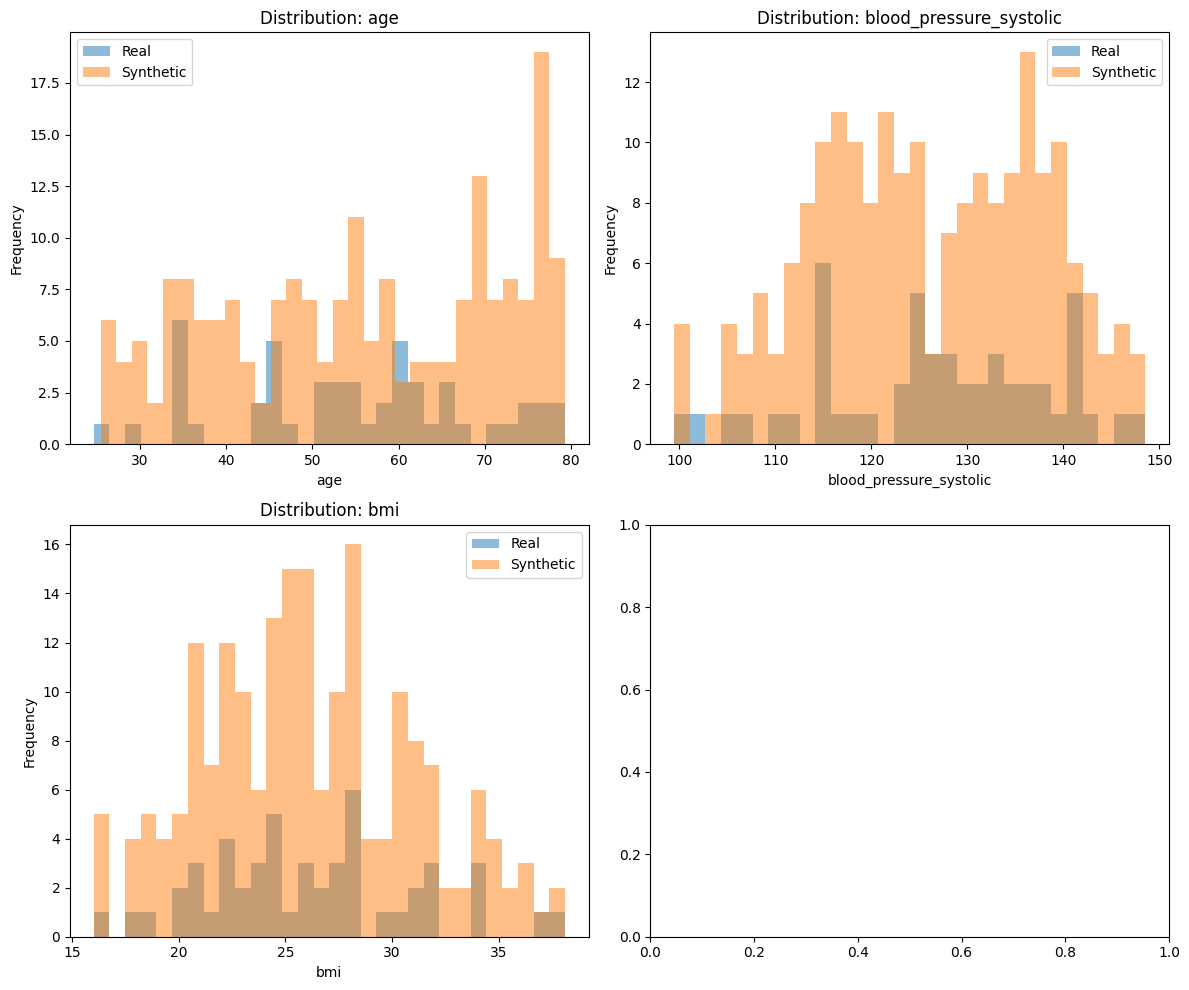

In [12]:
# Validate the synthetic data
print("Validating synthetic data quality...\n")

validation_results = pipeline.validator.validate_statistical_similarity(
    sample_df, sdv_synthetic
)

print("Statistical Similarity Results:")
print("=" * 50)
for column, metrics in validation_results.items():
    print(f"\n{column}:")
    print(f"  Similar distribution: {metrics['similar']}")
    print(f"  KS statistic: {metrics['ks_statistic']:.4f}")
    print(f"  p-value: {metrics['p_value']:.4f}")
    print(f"  Real mean: {metrics['real_mean']:.2f}, Synthetic mean: {metrics['synthetic_mean']:.2f}")
    print(f"  Real std: {metrics['real_std']:.2f}, Synthetic std: {metrics['synthetic_std']:.2f}")

privacy_check = pipeline.validator.check_privacy(sample_df, sdv_synthetic)
print("\n" + "=" * 50)
print("\nPrivacy Validation Results:")
print(f"  Mean minimum distance to real records: {privacy_check['mean_min_distance']:.4f}")
print(f"  Privacy risk level: {privacy_check['privacy_risk']}")

# Visualize the comparison
print("\nGenerating comparison visualizations...")
pipeline.validator.visualize_comparison(
    sample_df, sdv_synthetic, 
    columns=['age', 'blood_pressure_systolic', 'bmi']
)

# Exercises

Now let's extend our synthetic data generation capabilities with additional features through hands-on exercises.

In these exercises, you'll work on advanced synthetic data generation techniques that handle more complex real-world scenarios. You'll implement multi-modal data generation (combining different data types) and build privacy validation frameworks - both critical skills for production synthetic data systems.

---


### Exercise 1 - Multi-Modal Data Generation

Real-world datasets often combine multiple data modalities - numerical measurements, categorical labels, free-text descriptions, and timestamps. Your task is to implement a multi-modal generator that can handle all these types cohesively.

**Scenario**: You need to generate synthetic e-commerce transaction data that includes:
- Numerical: transaction amount, quantity, customer age
- Categorical: product category, payment method
- Text: product description, customer review
- Temporal: transaction timestamp

**Instructions**: Complete the `MultiModalGenerator` class below. Follow the TODOs to implement methods for generating different data modalities and combining them into a unified dataset.


In [209]:
class MultiModalGenerator:
    """
    Generate synthetic data across multiple modalities.
    """
    def __init__(self, llm, seed: int = 42):
        self.llm = llm
        self.faker = Faker()
        Faker.seed(seed)
        self.rng = np.random.RandomState(seed)
        self.llm_generator = LLMDataGenerator(llm)
    
    def generate_temporal_data(self, num_records: int, 
                              start_date: datetime, 
                              end_date: datetime) -> List[datetime]:
        """
        Generate synthetic timestamp data.
        
        Args:
            num_records (int): Number of timestamps to generate
            start_date (datetime): Start of date range
            end_date (datetime): End of date range
            
        Returns:
            List[datetime]: List of generated timestamps
        """
        
        time_delta = (end_date - start_date).total_seconds()
        
        offsets = self.rng.uniform(0, time_delta,num_records)

        timestamps = [start_date + timedelta(seconds=offset) for offset in offsets]
        
        return sorted(timestamps)
    
    def generate_multimodal_dataset(self, schema: Dict[str, Any], 
                                   num_records: int) -> pd.DataFrame:
        """
        Generate a complete multi-modal synthetic dataset.
        
        Args:
            schema (Dict[str, Any]): Schema defining all modalities
            num_records (int): Number of records to generate
            
        Returns:
            pd.DataFrame: Multi-modal synthetic dataset
        """
        data = {}

        sampler = StatisticalSampler()
        text_schema = {}
        
        for field, config in schema.items():
            modality = config.get('modality', 'numerical')
            
            if modality == 'numerical':
                dist = config.get('distribution', 'normal')
                params = config.get('params', {})
                data[field] = sampler.sample_numerical(dist, num_records, **params)

            elif modality == 'categorical':
                categories = config.get('categories', [])
                probabilities = config.get('probabilities',None)
                data[field] = sampler.sample_categorical(categories, num_records,probabilities) 

            elif modality == 'temporal':
                start_date = config.get('start_date')
                end_date = config.get('end_date')
                data[field] = self.generate_temporal_data(num_records, start_date, end_date)

            elif modality == 'text':
                text_schema[field] = config

        
        data  = pd.DataFrame(data)                
        counts = data['prod_category'].value_counts()

        for product, count in counts.items():
            llm_out = self.llm_generator.generate_records(text_schema,count,f'Create product descriptions and reviews for the following product: {product}')
            product_desc = [item['product_desc']['description'] for item in llm_out]
            review = [item['review']['description'] for item in llm_out]

            data.loc[data['prod_category'] == product, 'product_desc'] = product_desc
            data.loc[data['prod_category'] == product, 'review'] = review

        return data

In [210]:
schema = {
    'amount': {
        'modality': 'numerical',
        'distribution': 'normal',
        'params': {'mean': 35, 'std': 10}
    },
    'quantity': {
        'modality': 'numerical',
        'distribution': 'randint',
        'params': {'low': 1, 'high': 5}
    },
    'age': {
        'modality': 'numerical',
        'distribution': 'randint',
        'params': {'low': 18, 'high': 70}
    },
    'prod_category': {
        'modality': 'categorical',
        'categories': ['Cellphone', 'Laptop', 'Console', 'TV'],
        'probabilities': [0.4, 0.1, 0.1, 0.4]
    },
    'payment_method': {
        'modality': 'categorical',
        'categories': ['credit_card', 'paypal', 'invoice'],
        'probabilities': [0.7, 0.2, 0.1]
    },
    'purchase_date': {
        'modality': 'temporal',
        'start_date': datetime(2024,1,1),
        'end_date': datetime(2024,12,31)
    },
    'product_desc': {
        'modality': 'text',
        'description': 'realistic product description'
    },
    'review': {
        'modality': 'text',
        'description': 'realistic product review, 1-2 sentences'
    }  
}

In [211]:
model = MultiModalGenerator(llm)

In [212]:
out = model.generate_multimodal_dataset(schema,10)

In [213]:
out

,amount,quantity,age,prod_category,payment_method,purchase_date,product_desc,review
0,39.967142,4,66,Console,credit_card,2024-01-22 04:48:44.793336,"The Orion X1 Console is a compact, living-room...",Great performance for the price — load times a...
1,33.617357,4,44,Cellphone,credit_card,2024-02-26 22:30:43.193322,6.4-inch AMOLED smartphone with 90Hz refresh r...,Battery easily lasts a full day with moderate ...
2,41.476885,1,59,TV,credit_card,2024-02-26 22:43:23.844993,"Aurora V55-OLED 55"" Smart OLED TV — 4K (3840x2...",Picture quality is breathtaking—deep blacks an...
3,50.230299,1,45,Cellphone,credit_card,2024-05-16 16:58:17.187970,Flagship 6.7-inch QHD+ OLED display with 120Hz...,The display and performance are top-tier and t...
4,32.658466,4,33,Cellphone,credit_card,2024-08-06 12:14:53.957638,Budget-oriented 6.5-inch LCD smartphone offeri...,Excellent entry-level device for basic tasks a...
5,32.658630,2,32,TV,invoice,2024-08-07 09:46:03.010334,"Nexis QX 65"" Quantum Dot LED — 65-inch 4K UHD ...","Bright, punchy HDR performance—sports look fan..."
6,50.792128,2,64,TV,credit_card,2024-09-15 10:42:56.813376,"Voltix S43 43"" 4K HDR Smart TV — compact 43-in...",Great value for a bedroom TV—crisp 4K upscalin...
7,42.674347,1,68,TV,credit_card,2024-09-24 04:16:00.948964,"Crestview X8 75"" Mini-LED 8K TV — flagship 75-...",This is a stunning centerpiece—upscaling makes...
8,30.305256,4,61,Cellphone,credit_card,2024-11-12 03:42:10.933158,Premium foldable with a 7.6-inch inner Foldabl...,The large inner screen is fantastic for multit...
9,40.425600,1,69,Cellphone,credit_card,2024-12-13 00:15:26.366943,Rugged 5.5-inch smartphone designed for field ...,"This phone survives drops, mud and long shifts..."


<details>
    <summary>Click here for Solution</summary>

```python
class MultiModalGenerator:
    """
    Generate synthetic data across multiple modalities.
    """
    def __init__(self, llm, seed: int = 42):
        self.llm = llm
        self.faker = Faker()
        Faker.seed(seed)
        self.rng = np.random.RandomState(seed)
        self.llm_generator = LLMDataGenerator(llm)
    
    def generate_temporal_data(self, num_records: int, 
                              start_date: datetime, 
                              end_date: datetime) -> List[datetime]:
        """
        Generate synthetic timestamp data.
        
        Args:
            num_records (int): Number of timestamps to generate
            start_date (datetime): Start of date range
            end_date (datetime): End of date range
            
        Returns:
            List[datetime]: List of generated timestamps
        """
        # Calculate time delta
        time_delta = (end_date - start_date).total_seconds()
        
        # Generate random offsets
        offsets = self.rng.uniform(0, time_delta, num_records)
        
        # Create timestamps
        timestamps = [start_date + timedelta(seconds=offset) for offset in offsets]
        
        # Sort and return
        return sorted(timestamps)
    
    def generate_multimodal_dataset(self, schema: Dict[str, Any], 
                                   num_records: int) -> pd.DataFrame:
        """
        Generate a complete multi-modal synthetic dataset.
        
        Args:
            schema (Dict[str, Any]): Schema defining all modalities
            num_records (int): Number of records to generate
            
        Returns:
            pd.DataFrame: Multi-modal synthetic dataset
        """
        data = {}
        
        for field, config in schema.items():
            modality = config.get('modality', 'numerical')
            
            if modality == 'numerical':
                dist = config.get('distribution', 'normal')
                params = config.get('params', {})
                sampler = StatisticalSampler()
                data[field] = sampler.sample_numerical(dist, num_records, **params)
            
            elif modality == 'categorical':
                categories = config.get('categories', [])
                probs = config.get('probabilities', None)
                data[field] = self.rng.choice(categories, num_records, p=probs)
            
            elif modality == 'text':
                description = config.get('description', '')
                text_samples = self.llm_generator.generate_text_field(description, num_records)
                data[field] = text_samples if len(text_samples) == num_records else [''] * num_records
            
            elif modality == 'temporal':
                start = config.get('start_date', datetime.now() - timedelta(days=365))
                end = config.get('end_date', datetime.now())
                data[field] = self.generate_temporal_data(num_records, start, end)
        
        return pd.DataFrame(data)
```

</details>

### Exercise 2 - Privacy Validation Framework


Privacy preservation is critical in synthetic data generation. Your task is to implement a comprehensive privacy validation framework that checks for potential re-identification risks.

**Scenario**: You need to ensure that your synthetic healthcare data doesn't inadvertently expose patient information through:
- Exact matches to real records
- Quasi-identifier combinations (e.g., age + zip code + gender) that could re-identify individuals
- Statistical disclosure (synthetic data that leaks information about specific individuals)

**Instructions**: Complete the `PrivacyValidator` class below to implement various privacy checks.


In [ ]:
class PrivacyValidator:
    """
    Comprehensive privacy validation for synthetic data.
    """
    @staticmethod
    def check_exact_matches(real_data: pd.DataFrame, 
                           synthetic_data: pd.DataFrame,
                           columns: Optional[List[str]] = None) -> Dict[str, Any]:
        """
        Check for exact matches between real and synthetic records.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset
            columns (Optional[List[str]]): Specific columns to check
            
        Returns:
            Dict[str, Any]: Match statistics and privacy assessment
        """
        # TODO 1: If columns not specified, use all columns
        # Hint: Use real_data.columns.tolist()
        
        # TODO 2: Create string representations of records for comparison
        # Hint: Use apply(lambda row: '|'.join(row.astype(str)), axis=1)
        
        # TODO 3: Find exact matches using set intersection
        # Hint: Use set(real_records) & set(synthetic_records)
        
        # TODO 4: Return results with match count and privacy risk level
        # Risk: HIGH if any matches, MEDIUM if close to matching, LOW otherwise
        
        pass
    
    @staticmethod
    def check_quasi_identifiers(real_data: pd.DataFrame,
                               synthetic_data: pd.DataFrame,
                               quasi_id_columns: List[str]) -> Dict[str, Any]:
        """
        Check if quasi-identifier combinations appear in both datasets.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset  
            quasi_id_columns (List[str]): Columns that form quasi-identifiers
            
        Returns:
            Dict[str, Any]: Quasi-identifier overlap statistics
        """
        # TODO 5: Group by quasi-identifier columns and count occurrences
        # Hint: Use groupby(quasi_id_columns).size()
        
        # TODO 6: Find quasi-identifier combinations that appear in both datasets
        # Hint: Use set intersection on the indices
        
        # TODO 7: Calculate k-anonymity (minimum group size)
        # Hint: Use the size() results to find minimum group sizes
        
        # TODO 8: Return comprehensive privacy metrics
        
        pass

<details>
    <summary>Click here for Solution</summary>

```python
class PrivacyValidator:
    """
    Comprehensive privacy validation for synthetic data.
    """
    @staticmethod
    def check_exact_matches(real_data: pd.DataFrame, 
                           synthetic_data: pd.DataFrame,
                           columns: Optional[List[str]] = None) -> Dict[str, Any]:
        """
        Check for exact matches between real and synthetic records.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset
            columns (Optional[List[str]]): Specific columns to check
            
        Returns:
            Dict[str, Any]: Match statistics and privacy assessment
        """
        if columns is None:
            columns = real_data.columns.tolist()
        
        # Create string representations of records
        real_records = real_data[columns].apply(
            lambda row: '|'.join(row.astype(str)), axis=1
        )
        synthetic_records = synthetic_data[columns].apply(
            lambda row: '|'.join(row.astype(str)), axis=1
        )
        
        # Find exact matches
        matches = set(real_records) & set(synthetic_records)
        
        num_matches = len(matches)
        match_percentage = (num_matches / len(synthetic_data)) * 100
        
        return {
            'exact_matches': num_matches,
            'match_percentage': match_percentage,
            'privacy_risk': 'HIGH' if num_matches > 0 else 'LOW',
            'recommendation': 'REJECT: Contains exact matches' if num_matches > 0 
                            else 'ACCEPT: No exact matches found'
        }
    
    @staticmethod
    def check_quasi_identifiers(real_data: pd.DataFrame,
                               synthetic_data: pd.DataFrame,
                               quasi_id_columns: List[str]) -> Dict[str, Any]:
        """
        Check if quasi-identifier combinations appear in both datasets.
        
        Args:
            real_data (pd.DataFrame): Original dataset
            synthetic_data (pd.DataFrame): Synthetic dataset
            quasi_id_columns (List[str]): Columns that form quasi-identifiers
            
        Returns:
            Dict[str, Any]: Quasi-identifier overlap statistics
        """
        # Group by quasi-identifiers
        real_groups = real_data.groupby(quasi_id_columns).size()
        synthetic_groups = synthetic_data.groupby(quasi_id_columns).size()
        
        # Find overlapping combinations
        overlap = set(real_groups.index) & set(synthetic_groups.index)
        
        # Calculate k-anonymity
        k_anonymity_real = real_groups.min() if len(real_groups) > 0 else 0
        k_anonymity_synthetic = synthetic_groups.min() if len(synthetic_groups) > 0 else 0
        
        overlap_percentage = (len(overlap) / len(synthetic_groups)) * 100 if len(synthetic_groups) > 0 else 0
        
        return {
            'overlapping_combinations': len(overlap),
            'overlap_percentage': overlap_percentage,
            'k_anonymity_real': k_anonymity_real,
            'k_anonymity_synthetic': k_anonymity_synthetic,
            'privacy_risk': 'HIGH' if overlap_percentage > 50 else 
                          'MEDIUM' if overlap_percentage > 20 else 'LOW',
            'recommendation': f'k-anonymity: {k_anonymity_synthetic} - ' + 
                            ('GOOD (≥5)' if k_anonymity_synthetic >= 5 else 'POOR (<5)')
        }
```

</details>


## Authors


[Tenzin Migmar](https://author.skills.network/instructors/tenzin_migmar): Hi, I'm Tenzin. I'm a data scientist intern at IBM interested in applying machine learning to solve difficult problems. Prior to joining IBM, I worked as a research assistant on projects exploring perspectivism and personalization within large language models. In my free time, I enjoy recreational programming and learning to cook new recipes.


### Other Contributors


[Jianping Ye](https://author.skills.network/instructors/jianping_ye): I'm Jianping Ye, currently a Data Scientist Intern at IBM and a PhD candidate at the University of Maryland. I specialize in designing AI solutions that bridge the gap between research and real-world application. With hands-on experience in developing and deploying machine learning models, I also enjoy mentoring and teaching others to unlock the full potential of AI in their work.


Copyright © 2026 IBM Corporation. All rights reserved.
